Installing SDK

In [1]:
!pip install -q -U google-generativeai

Setting up API key and Initializing the Generative Model

In [2]:
from google.colab import userdata
from google import genai
from google.genai.types import GenerateContentConfig, HttpOptions

MODEL_NAME = "gemini-2.0-flash"
instruction = "You are an expert of linguistics and personal health experience."

# Initialize the Gemini client with the API key
GOOGLE_API_KEY = userdata.get('NEW_GOOGLE_API_KEY')
client = genai.Client(api_key=GOOGLE_API_KEY)

# Request the model to generate content with JSON response format and schema
response = client.models.generate_content(
    model=MODEL_NAME,
    #system_instruction=instruction,
    contents="Hello! Can you respond?",
    config=GenerateContentConfig(
        system_instruction=instruction,
        response_mime_type='application/json'  # Specify the response format
    )
)

# Print the response as JSON string
print(response.text)

{
  "response": "Hello! How can I help you today? I can assist you with questions related to linguistics or share my experiences regarding personal health."
}


Defining drive paths

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define Folder Path
DRIVE = "/content/drive"
FOLDER_DATA = r"/content/drive/My Drive/Thesis/Classification/Data/"

# Define the dataset filename
DATA_FILE_NAME_TWEETS = "tweet-text-with-annotations.txt"
DATA_FILE_EXT = ".txt"

# Full Path to Data File
DATA_FILE_PATH = FOLDER_DATA + DATA_FILE_NAME_TWEETS


Mounted at /content/drive


Reading data

In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv(DATA_FILE_PATH, delimiter="\t", encoding="utf-8", quoting=3)
# quoting=3 tells pandas to treat quotes (") as regular characters instead of special text delimiters
# prevents parsing errors caused by inconsistent or excessive quotation marks

# Extract tweet numbers and text
#tweet_numbers = df["Tweet #"].tolist()
tweets_list = df["Tweet Text"].tolist()

#test_tweet_numbers = df["Tweet #"].tolist()
#test_tweets_list = df["Tweet Text"].tolist()

# Select only the first 10 tweets for testing
#tweet_numbers = test_tweet_numbers[:10]
#tweets_list = test_tweets_list[:10]

Creating classification function

In [5]:
import json
import time

# List to store execution times
execution_times = []

# List to store token counts
token_counts = []

def classify_tweets_batch(tweet_text):
    prompt = """
    Task: Classify each line of text between [begin] and [end] into one of two classes:
    - "Yes": The text explicitly describes a personal health experience directly related to the mentioned medication, with clear reference to personal symptoms, effects, or reactions.
    - "No": The text does NOT describe a personal health experience. It is a question, opinion, general discussion, medical fact, hypothetical scenario, lacks direct first-person experience, or is ambiguous.

    Instructions:
    - Return EXACTLY {} classifications for {} input lines.
    - Do NOT assume information; base the classification ONLY on the given text.
    - Return the output in valid JSON format with line numbers as keys and classifications as values.

    [begin]
    """.format(len(tweet_text), len(tweet_text)) + "\n".join([f"{i+1}. {tweet}" for i, tweet in enumerate(tweet_text)]) + "\n[end]"

    #print(prompt)

    # Calculate token count
    #token_usage = model.count_tokens(prompt).total_tokens  # Get total tokens used in prompt
    #token_counts.append(token_usage)  # Store tokens used for this batch
    #print(f"Tokens used for this batch: {token_usage}")

    start_time = time.time()

    # Request the model to generate content with JSON response format and schema
    response = client.models.generate_content(
        model=MODEL_NAME,
        #system_instruction=instruction,
        contents=prompt,
        config=GenerateContentConfig(
            system_instruction=instruction,
            response_mime_type='application/json'  # Specify the response format
        )
    )

    end_time = time.time()  # End time tracking

    batch_time = end_time - start_time  # Calculate time for this batch
    execution_times.append(batch_time)  # Store it

    #print(f"Execution Time for this batch: {batch_time:.4f} seconds")

    #print("Raw Response:", response.text)  # Debugging line
     # Clean response by removing backticks and json label if present
    clean_response = response.text.strip().strip("```").replace("json", "").strip()

    try:
        return json.loads(clean_response) if response else {}
    except json.JSONDecodeError:
        print("Warning: Failed to parse JSON. Returning empty dict.")
        return {}

Creating batches and applying the classification function

In [6]:
import time
import json

# Define batch size
batch_size = 1000

# Create sequential tweet numbers
tweet_numbers = list(range(1, len(tweets_list) + 1))

# Store classification results
classified_labels = {}

for i in range(0, len(tweets_list), batch_size):
    batch_tweets = tweets_list[i:i + batch_size]

    # Get predictions
    results = classify_tweets_batch(batch_tweets)  # Should return a dictionary

    if results:  # Ensure results are valid
        # Adjust batch-local numbering to global numbering
        corrected_results = {str(i + int(k)): v for k, v in results.items()}

        # Store results without overwriting previous batches
        classified_labels.update(corrected_results)

    print(f"Completed batch {i // batch_size + 1}")

    # Prevent exceeding RPM limits
    #time.sleep(4)  # Ensures at most 15 requests per minute

# Calculate the total execution time
total_time = sum(execution_times)

# Calculate the average execution time
average_time = sum(execution_times) / len(execution_times)

print(f"\nTotal classified tweets: {len(classified_labels)}")
print(f"\nTotal Execution Time (exluding delay): {total_time:.4f} seconds")
print(f"\nAverage Execution Time per Batch (exluding delay): {average_time:.4f} seconds")

Completed batch 1
Completed batch 2
Completed batch 3
Completed batch 4
Completed batch 5
Completed batch 6
Completed batch 7
Completed batch 8
Completed batch 9
Completed batch 10
Completed batch 11
Completed batch 12
Completed batch 13

Total classified tweets: 331

Total Execution Time (exluding delay): 513.7447 seconds

Average Execution Time per Batch (exluding delay): 39.5188 seconds


Saving results to CSV

In [ ]:
print(classified_labels)

{'1': 'No', '2': 'No', '3': 'No', '4': 'No', '5': 'Yes', '6': 'No', '7': 'No', '8': 'No', '9': 'No', '10': 'No'}


In [ ]:
print(f"Total tweets sent: {len(tweet_numbers)}")
print(f"Total results received: {len(classified_labels)}")

Total tweets sent: 12331
Total results received: 11931


In [ ]:
import pandas as pd

# Define output file path
OUTPUT_FILE_PATH = "/content/drive/My Drive/Thesis/Classification/Data/Google Gemini 2.0 Flash Results/Without Delay/classified-tweets-batch-750.txt"

if isinstance(classified_labels, dict) and len(classified_labels) > 0:
    # Extract sorted labels based on fixed numbering
    sorted_labels = [classified_labels[key] for key in sorted(classified_labels.keys(), key=int)]  # Sort keys numerically

    # Generate continuous numbering
    serial_numbers = list(range(1, len(sorted_labels) + 1))

    # Create DataFrame
    df_output = pd.DataFrame({"Tweet #": serial_numbers, "Prediction": sorted_labels})

    # Save to CSV file
    df_output.to_csv(OUTPUT_FILE_PATH, index=False, sep="\t", encoding="utf-8")

    print(f"Classified tweets saved successfully at: {OUTPUT_FILE_PATH}")
else:
    print("Error: classified_labels is empty or not in expected JSON format.")


Classified tweets saved successfully at: /content/drive/My Drive/Thesis/Classification/Data/Google Gemini 2.0 Flash Results/Without Delay/classified-tweets-batch-750.txt


Converting labels to find Accuracy, Precision, Recall, F1, and AUC

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Load classified predictions
df_predictions = pd.read_csv(OUTPUT_FILE_PATH, delimiter="\t", encoding="utf-8")
print(df_predictions)

# Load original dataset (true labels)
print(df)

# Ensure that different cases and accidental spaces do not cause issues.
y_true = df["Annotation"].str.strip().str.lower().map({"yes": 1, "no": 0})
y_pred = df_predictions["Prediction"].str.strip().str.lower().map({"yes": 1, "no": 0})

       Tweet # Prediction
0            1         No
1            2         No
2            3         No
3            4         No
4            5        Yes
...        ...        ...
12326    12327         No
12327    12328         No
12328    12329         No
12329    12330         No
12330    12331         No

[12331 rows x 2 columns]
                                              Tweet Text Annotation
0           """PERSON  yes or play """"*MEDICINE*"""""""         No
1      PERSON see the ritalin crab turns you antisemitic         No
2      PERSON do you realize how bad the *MEDICINE* p...         No
3      PERSON I got some *MEDICINE* if you actually s...         No
4      So as it turns out  I'm very much allergic to ...        Yes
...                                                  ...        ...
12326  Question: Is halcion are *MEDICINE* better for...        Yes
12327  Question: Is halcion are *MEDICINE* better for...        Yes
12328  "PERSON PERSON I needed happy pills yrs ago

Computing ML metrics



Classification Performance Metrics
----------------------------------
Accuracy: 0.7885
Precision: 0.5386
Recall: 0.8342
F1 Score: 0.6546
AUC Score: 0.8041


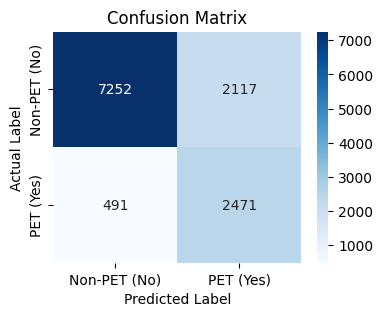

In [ ]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_pred)

# Print results
print("\nClassification Performance Metrics")
print("----------------------------------")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC Score: {auc:.4f}")

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix using seaborn
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-PET (No)", "PET (Yes)"], yticklabels=["Non-PET (No)", "PET (Yes)"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()